# Бонусное домашнее задание

## Part 0

В данном домашнем задании вам предстоит реализовать СLIP -- self-supervision модель которая выучивает зависимости между картинками и текстов в едином векторном пространстве. Для выполнения этого домашнего задания вам понадобится GPU и несколько дополнительных библиотек. Автор рекомендует делать все исключительно в Kaggle. 


[Ссылка на датасет](https://www.kaggle.com/datasets/keenwarrior/small-flicker-data-for-image-captioning)

[Ссылка на статью](https://openai.com/research/clip)

Задания в ноутбуке будут во многом опираться на статью, поэтому рекомендуется ее прочитать перед выполнением.

In [1]:
# !pip install timm
# !pip install transformers

In [2]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import os
import glob
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import pandas as pd
import timm
PATH_TO_IMAGES = "/home/werserk/05-personal/hse/intro-to-dl-hse/homeworks-small/shw-04-ssl/data/images"
PATH_TO_CAPTIONS = "/home/werserk/05-personal/hse/intro-to-dl-hse/homeworks-small/shw-04-ssl/data/captions.csv"

## Part 1 (8 баллов)

Для начала нам нужно реализовать составляющие модели: Кодировщик картинок, текста и проектор на какое-то маломерное пространство. В папке с заданием есть соответствующие файлы, заполните пропуски в них опираясь на docstring-и.

Разбалловка следующая: 

Правильно реализованные кодировщики: 2 балла.

Правильно реализованный проектор: 2 балла.

Правильно реализованный класс СLIP: 4 балла.

In [3]:
from CLIPDataset import CLIPDataset
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer
from ImageEncoder import ImageEncoder
from ProjectionHead import ProjectionHead
from TextEncoder import TextEncoder

In [4]:
class CLIP(nn.Module):
    def __init__(self, image_embedding=2048, text_embedding=768, projection_dim=256, dropout=0.1, temp=1.0):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projections = ProjectionHead(embedding_dim=image_embedding, projection_dim=projection_dim, dropout=dropout)
        self.text_projections = ProjectionHead(embedding_dim=text_embedding, projection_dim=projection_dim, dropout=dropout)
        self.temp = temp
    def forward(self, batch):
        """
        :batch: dict of images and text
        Here is what you should do:
        1) extract image and text features from batch
        2) project features into projection space (small latent space)
        3) compute cosine similarity with temperature this will be your logits
        4) compute "true" logits (eg. cosine similarity between images and images, text and text)
        5) create targets by averaging similarities from step above (do not forget about temperature)
        6) compute mean loss (see paper)
        7) return loss

        Overall: read paper.
        
        """
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(batch["input_ids"], batch["attention_mask"])

        image_embeddings = self.image_projections(image_features)
        text_embeddings = self.text_projections(text_features)

        image_embeddings = nn.functional.normalize(image_embeddings, p=2, dim=-1)
        text_embeddings = nn.functional.normalize(text_embeddings, p=2, dim=-1)
        
        logits = (image_embeddings @ text_embeddings.T) / self.temp

        images_similarity = image_embeddings @ image_embeddings.T
        texts_similarity = text_embeddings @ text_embeddings.T
        
        targets = nn.functional.softmax(
            (images_similarity + texts_similarity) / (2 * self.temp), dim=-1
        )

        texts_loss = CE(logits, targets)
        images_loss = CE(logits.T, targets.T)
        loss = (images_loss + texts_loss) / 2.0
        
        return loss.mean()
    

def CE(preds, targets):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    return loss   

# Part 2. (0 Баллов)

Здесь вам нужно вписать правильный путь до csv файла на своей машине и запустить код.

In [5]:
def make_train_valid_dfs():
    dataframe = pd.read_csv(f"{PATH_TO_CAPTIONS}")
    dataframe["id"] = np.array(list(dataframe.index))
    max_id = dataframe["id"].max() + 1
    image_ids = np.arange(0, max_id)
    np.random.seed(42)
    valid_ids = np.random.choice(
        image_ids, size=int(0.2 * len(image_ids)), replace=False
    )
    train_ids = [id_ for id_ in image_ids if id_ not in valid_ids]
    train_dataframe = dataframe[dataframe["id"].isin(train_ids)].reset_index(drop=True)
    valid_dataframe = dataframe[dataframe["id"].isin(valid_ids)].reset_index(drop=True)
    return train_dataframe, valid_dataframe

In [6]:
def build_loaders(dataframe, tokenizer, mode, batch_size=32):
    dataset = CLIPDataset(
        PATH_TO_IMAGES,
        dataframe["image"].values,
        dataframe["caption"].values,
        tokenizer=tokenizer
    )
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=1,
        shuffle=True if mode == "train" else False,
    )
    return dataloader, dataset

In [7]:
class AvgMeter:
    def __init__(self, name="CrossEntropyLoss"):
        self.name = name
        self.reset()

    def reset(self):
        self.avg, self.sum, self.count = [0] * 3

    def update(self, val, count=1):
        self.count += count
        self.sum += val * count
        self.avg = self.sum / self.count

    def __repr__(self):
        text = f"{self.name}: {self.avg:.4f}"
        return text
    
    def __format__(self, formatspec):
        text = f"{self.name}: {format(self.avg, formatspec)}"
        return text

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

In [8]:
def train(model, train_loader, optimizer, lr_scheduler, step):
    loss_meter = AvgMeter()
    for batch in train_loader:
        batch = {key: value.to(device) for key, value in batch.items() if key != "caption"}
        loss = model(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step == "batch":
            lr_scheduler.step()
        loss_meter.update(loss.item(), batch["image"].shape[0])
    return loss_meter

@torch.no_grad()
def validate(model, validation_loader):
    loss_meter = AvgMeter()
    for batch in validation_loader:
        batch = {key: value.to(device) for key, value in batch.items() if key != "caption"}
        loss = model(batch)
        loss_meter.update(loss.item(), batch["image"].shape[0])
    return loss_meter

## Part 3. (2 балла)

За вас написан минимальный код для обучения, если он запускается и модель учится, то за этот пункт вы получите 0.5 балла. Чтобы получить полный балл за задание вам нужно будет провести несколько экспериментов и поподбирать гиперпараметры. Можно начать со статьи.

In [9]:
import itertools
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCH = 10
def procedure(config=None, trial=None):
    if config is None:
        config = {
            "lr": 1e-3,
            "weight_decay": 0.0,
            "batch_size": 32,
            "epochs": 10,
            "temp": 1.0,
            "projection_dim": 256,
            "dropout": 0.1
        }
    
    train_df, validation_df = make_train_valid_dfs()
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    train_loader, _ = build_loaders(train_df, tokenizer, mode="train", batch_size=config["batch_size"])
    val_loader, _ = build_loaders(validation_df, tokenizer, mode="valid", batch_size=config["batch_size"])
    
    model = CLIP(
        temp=config["temp"],
        projection_dim=config["projection_dim"],
        dropout=config["dropout"]
    ).to(device)
    
    params = [{"params": model.image_encoder.parameters()},
              {"params": model.text_encoder.parameters()},
              {"params": itertools.chain(model.image_projections.parameters(),
                                          model.text_projections.parameters())}]
    
    optimizer = torch.optim.Adam(params, lr=config["lr"], weight_decay=config["weight_decay"])
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.8)
    step = "epoch"
    
    best_val_loss = float("inf")
    history = []
    
    for epoch in tqdm(range(config["epochs"]), desc="Epochs"):
        model.train()
        train_loss = train(model, train_loader, optimizer, lr_scheduler, step)
        
        model.eval()
        val_loss = validate(model, val_loader)
        
        lr_scheduler.step(val_loss.avg)
        
        if val_loss.avg < best_val_loss:
            best_val_loss = val_loss.avg
            
        curr_lr = get_lr(optimizer)
        
        epoch_metrics = {
            "epoch": epoch,
            "train_loss": train_loss.avg,
            "val_loss": val_loss.avg,
            "best_val_loss": best_val_loss,
            "lr": curr_lr
        }
        history.append(epoch_metrics)
        
        print(f"Epoch: {epoch:02d} | Train Loss: {train_loss.avg:.4f} | Val Loss: {val_loss.avg:.4f} | Best Val: {best_val_loss:.4f} | LR: {curr_lr:.2e}")
        
        if trial is not None:
            trial.report(val_loss.avg, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
                
    return model, history, best_val_loss

In [10]:
import optuna
import time

TIMEOUT = 1800
start_time = time.time()

def objective(trial):
    elapsed_time = time.time() - start_time
    remaining_time = max(0, TIMEOUT - elapsed_time)
    
    config = {
        "lr": trial.suggest_float("lr", 1e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "epochs": 5,  # Reduced for sweep speed
        "temp": trial.suggest_float("temp", 0.05, 1.0),
        "projection_dim": trial.suggest_categorical("projection_dim", [128, 256, 512]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.3)
    }
    
    print(f"\n>>> Trial {trial.number} starting. Remaining time: {remaining_time/60:.1f} min")
    print(f"Config: {config}")
    
    try:
        _, _, best_val_loss = procedure(config, trial=trial)
    except optuna.TrialPruned:
        print(f"<<< Trial {trial.number} pruned.")
        raise
        
    print(f"<<< Trial {trial.number} finished. Best Val Loss: {best_val_loss:.4f}")
    return best_val_loss

study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10, timeout=TIMEOUT)

print("\nBest trial:")
print(f"  Value: {study.best_trial.value:.4f}")
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-03-21 16:16:37,445] A new study created in memory with name: no-name-7199ea06-4735-4ef4-b488-042808afcb0e



>>> Trial 0 starting. Remaining time: 30.0 min
Config: {'lr': 3.6794449204419376e-05, 'weight_decay': 0.0008857398273396656, 'batch_size': 32, 'epochs': 5, 'temp': 0.333007288294597, 'projection_dim': 256, 'dropout': 0.09547020046851516}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-21 16:26:44,915] Trial 9 pruned. 


Epoch: 00 | Train Loss: 4.1498 | Val Loss: 4.0780 | Best Val: 4.0780 | LR: 1.08e-04
<<< Trial 9 pruned.

Best trial:
  Value: 1.7047
  Params: 
    lr: 1.9003494115693332e-05
    weight_decay: 2.5563708741319192e-05
    batch_size: 16
    temp: 0.13968682172714655
    projection_dim: 256
    dropout: 0.024551900995635468


In [11]:
best_config = study.best_trial.params.copy()
best_config["epochs"] = 10

model, history, _ = procedure(best_config)

best_config = study.best_trial.params.copy()
best_config["epochs"] = 10

model, history, _ = procedure(best_config)

history_df = pd.DataFrame(history)
history_df.to_csv("training_history.csv", index=False)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 00 | Train Loss: 2.6650 | Val Loss: 2.3371 | Best Val: 2.3371 | LR: 1.90e-05
Epoch: 01 | Train Loss: 2.0986 | Val Loss: 1.9793 | Best Val: 1.9793 | LR: 1.90e-05
Epoch: 02 | Train Loss: 1.8520 | Val Loss: 1.8519 | Best Val: 1.8519 | LR: 1.90e-05
Epoch: 03 | Train Loss: 1.7211 | Val Loss: 1.7696 | Best Val: 1.7696 | LR: 1.90e-05
Epoch: 04 | Train Loss: 1.6151 | Val Loss: 1.7039 | Best Val: 1.7039 | LR: 1.90e-05
Epoch: 05 | Train Loss: 1.5253 | Val Loss: 1.6454 | Best Val: 1.6454 | LR: 1.90e-05
Epoch: 06 | Train Loss: 1.4517 | Val Loss: 1.6033 | Best Val: 1.6033 | LR: 1.90e-05
Epoch: 07 | Train Loss: 1.3851 | Val Loss: 1.5551 | Best Val: 1.5551 | LR: 1.90e-05
Epoch: 08 | Train Loss: 1.3436 | Val Loss: 1.5263 | Best Val: 1.5263 | LR: 1.90e-05
Epoch: 09 | Train Loss: 1.2860 | Val Loss: 1.4892 | Best Val: 1.4892 | LR: 1.90e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 00 | Train Loss: 2.6813 | Val Loss: 2.3675 | Best Val: 2.3675 | LR: 1.90e-05
Epoch: 01 | Train Loss: 2.1094 | Val Loss: 1.9657 | Best Val: 1.9657 | LR: 1.90e-05
Epoch: 02 | Train Loss: 1.8598 | Val Loss: 1.8539 | Best Val: 1.8539 | LR: 1.90e-05
Epoch: 03 | Train Loss: 1.7026 | Val Loss: 1.7701 | Best Val: 1.7701 | LR: 1.90e-05
Epoch: 04 | Train Loss: 1.6036 | Val Loss: 1.7035 | Best Val: 1.7035 | LR: 1.90e-05
Epoch: 05 | Train Loss: 1.5046 | Val Loss: 1.6469 | Best Val: 1.6469 | LR: 1.90e-05
Epoch: 06 | Train Loss: 1.4309 | Val Loss: 1.5961 | Best Val: 1.5961 | LR: 1.90e-05
Epoch: 07 | Train Loss: 1.3693 | Val Loss: 1.5429 | Best Val: 1.5429 | LR: 1.90e-05
Epoch: 08 | Train Loss: 1.3102 | Val Loss: 1.5073 | Best Val: 1.5073 | LR: 1.90e-05
Epoch: 09 | Train Loss: 1.2594 | Val Loss: 1.4796 | Best Val: 1.4796 | LR: 1.90e-05


## Part 4 (0 баллов)

Просто посмотрим на результаты.

In [12]:
@torch.inference_mode()
def get_image_embeddings(valid_df, model):
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    valid_loader, _ = build_loaders(valid_df, tokenizer, mode="valid")
    valid_image_embeddings = []
    for batch in tqdm(valid_loader, desc="Getting embeddings", total=len(valid_loader)):
        batch = {key: value.to(device) for key, value in batch.items() if key != "caption"}
        image_features = model.image_encoder(batch["image"]).to(device)
        image_embeddings = model.image_projections(image_features)
        valid_image_embeddings.append(image_embeddings)
    return torch.cat(valid_image_embeddings)

In [13]:
import matplotlib.pyplot as plt
@torch.inference_mode()
def find_match(model, image_embeddings, text, image_filenames, num_examples=4):
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    text_encoded = tokenizer([text])
    batch = {key : torch.tensor(value).to(device) for key, value in text_encoded.items()}
    
    text_features = model.text_encoder(batch["input_ids"], batch["attention_mask"])
    text_embeddings = model.text_projections(text_features)
    
    norm_image_embeddings = nn.functional.normalize(image_embeddings, p=2, dim=-1)
    norm_text_embeddings = nn.functional.normalize(text_embeddings, p=2, dim=-1)
    
    similarity = norm_text_embeddings @ norm_image_embeddings.T
    
    ans, ans_index = torch.topk(similarity.squeeze(0), num_examples * 5)
    match = [image_filenames[index] for index in ans_index[::5]]
    fig, ax = plt.subplots(int(num_examples/2), int(num_examples/2), figsize= (10, 10))
    for m, a in zip(match, ax.flatten()):
        image = Image.open(f"{PATH_TO_IMAGES}" + f"/{m}")
        image = image.convert("RGB")
        a.imshow(image)
        a.axis("off")
    plt.show()
    

In [14]:
_, valid_df = make_train_valid_dfs()
image_embeddings = get_image_embeddings(valid_df, model)

Getting embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

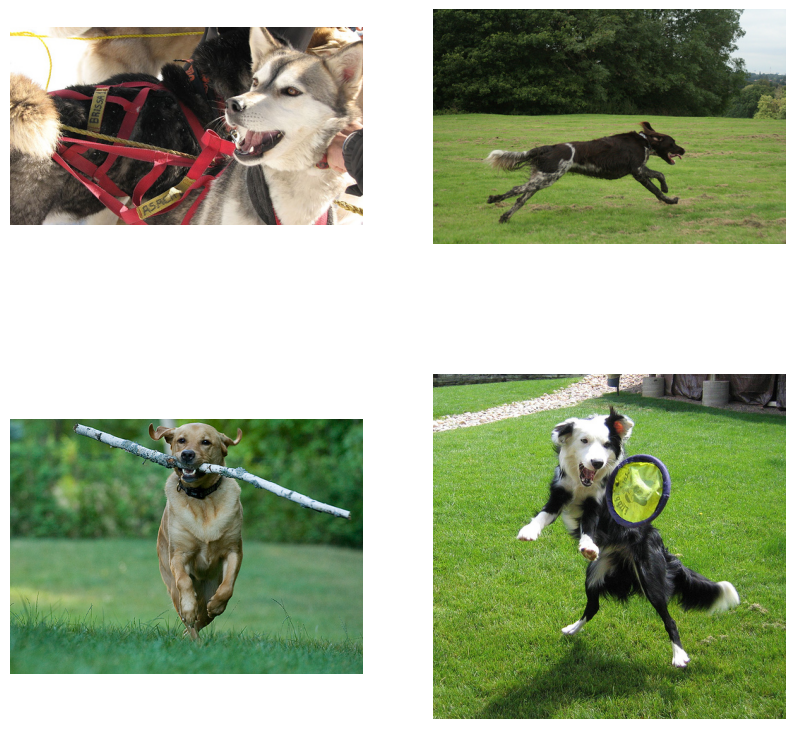

In [15]:
find_match(model, image_embeddings, "dogs", valid_df["image"].values)

## Опишите свои результаты.

> Результат: собака.
> Ну а вообще не знаю, что здесь описывать. Сделал всё по заданию. Перебирать руками гиперпараметры в 2к26 показалось странным, просто накинул оптуну.